In [1]:
import pandas as pd
import numpy as nm

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score
from sklearn.compose import ColumnTransformer

In [2]:
data = pd.read_csv('Student_Performance.csv')

In [3]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [18]:
data.shape

(10000, 6)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 493.2 KB


In [5]:
data.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

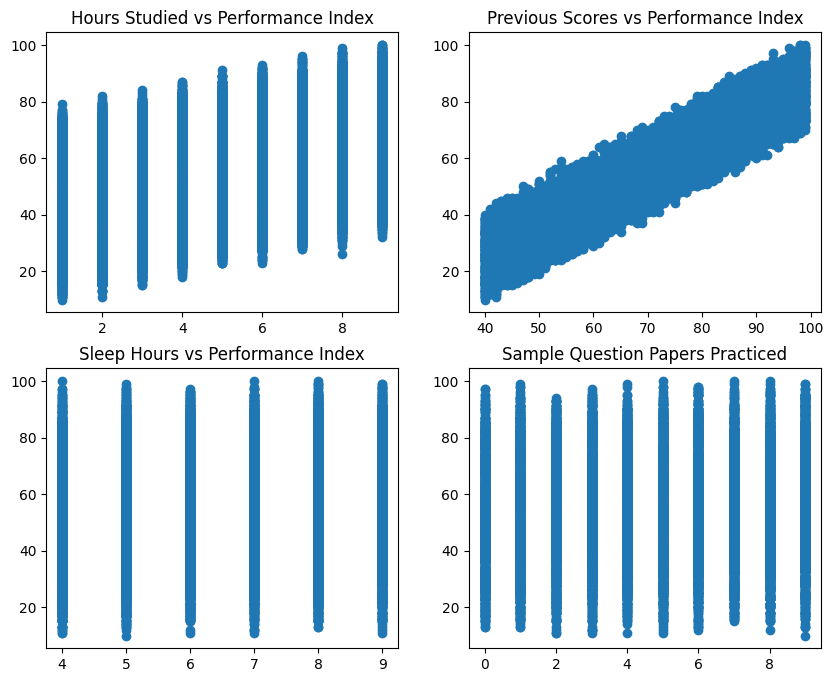

In [17]:
fig, ax = plt.subplots(2,2, figsize=(10,8))

ax[0,0].scatter(data['Hours Studied'], data['Performance Index'])
ax[0,0].set_title('Hours Studied vs Performance Index')
ax[0,1].scatter(data['Previous Scores'], data['Performance Index'])
ax[0,1].set_title('Previous Scores vs Performance Index')
ax[1,0].scatter(data['Sleep Hours'], data['Performance Index'])
ax[1,0].set_title('Sleep Hours vs Performance Index')
ax[1,1].scatter(data['Sample Question Papers Practiced'], data['Performance Index'])
ax[1,1].set_title('Sample Question Papers Practiced')

plt.show()

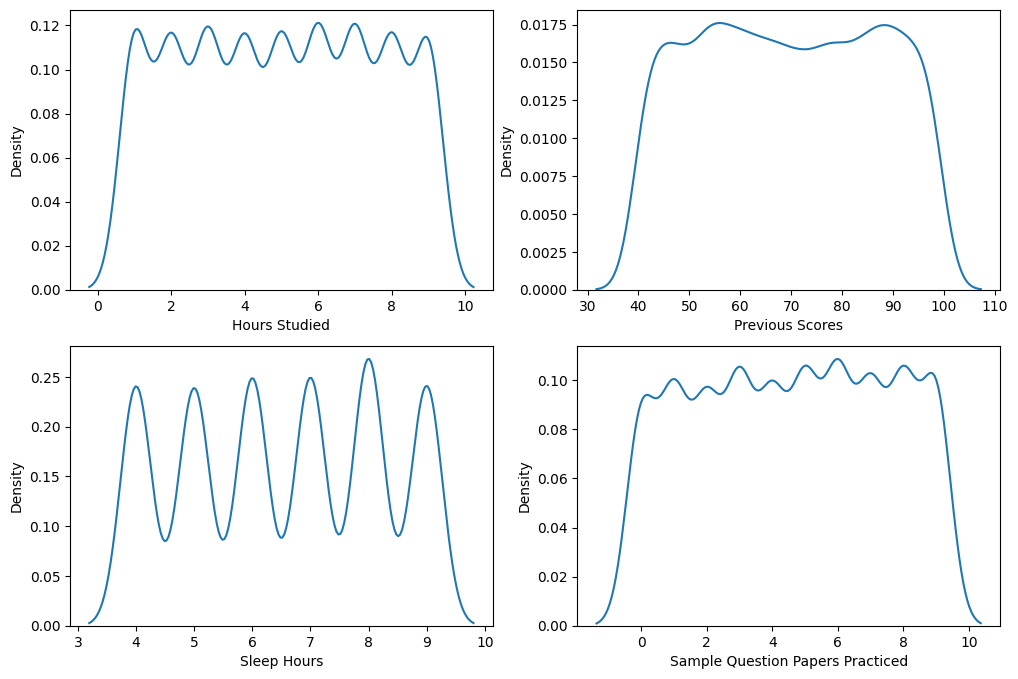

In [41]:
fig, ax = plt.subplots(2,2, figsize=(12,8))

sns.kdeplot(data['Hours Studied'], ax=ax[0,0])

sns.kdeplot(data['Previous Scores'], ax=ax[0,1])

sns.kdeplot(data['Sleep Hours'], ax=ax[1,0])

sns.kdeplot(data['Sample Question Papers Practiced'], ax=ax[1,1])


plt.show()

# Dividing the data into train & test

In [25]:
X = data.drop(columns=['Performance Index'])
y = data['Performance Index']

In [28]:
y.shape

(10000,)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [30]:
X_train

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
8856,9,82,Yes,7,8
1545,7,76,No,8,8
8136,9,47,No,5,7
7768,3,60,Yes,9,1
7782,9,88,No,9,6
...,...,...,...,...,...
1099,5,87,Yes,5,9
2514,6,56,No,4,3
6637,2,98,No,8,3
2575,8,45,No,8,7


## Applying OneHot Encoder for Categorical Column

In [31]:
ct = ColumnTransformer(transformers=[
    ('Extracurricular Activities', OneHotEncoder(drop='first', sparse_output=False), ['Extracurricular Activities'])
], remainder='passthrough')

In [34]:
X_train = ct.fit_transform(X_train)
X_test =ct.transform(X_test)

In [36]:
X_train.shape

(8000, 5)

In [42]:
lr = LinearRegression()

In [43]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
y_pred = lr.predict(X_test)

In [45]:
r2_score(y_test, y_pred)

0.9890954655668952